In [23]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
# ----------------------------
# torch helpers
# ----------------------------
def wrap01_torch(x: torch.Tensor) -> torch.Tensor:
    return x - torch.floor(x)

def torus_delta_torch(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # minimal signed displacement in [-0.5, 0.5)
    return torch.remainder(x - y + 0.5, 1.0) - 0.5

def make_shifts_torch(d: int, M: int, device=None, dtype=torch.float32) -> torch.Tensor:
    # (S,d) integer lattice shifts in [-M, M]^d
    rng = torch.arange(-M, M + 1, device=device, dtype=dtype)
    grids = torch.meshgrid(*([rng] * d), indexing="ij")
    return torch.stack([g.reshape(-1) for g in grids], dim=1)

def make_shifts(d: int, M: int) -> np.ndarray:
    grids = np.meshgrid(*([np.arange(-M, M + 1)] * d), indexing="ij")
    return np.stack(grids, axis=-1).reshape(-1, d)  # (S,d), S=(2M+1)^d
def wrap01(x):
    return x % 1.0
# ----------------------------
# GRW (your integrator) on GPU
# ----------------------------
@torch.no_grad()
def GRW_torch(X0, b, T: float, n_steps: int, end_only=False, seed=0):
    """
    Matches your NumPy GRW:
      X_{i+1} = (X_i + h*b(t_mid, X_i) + sqrt(h) * N(0,I)) mod 1
    """
    device = X0.device
    dtype = X0.dtype

    h = T / n_steps
    p, d = X0.shape

    X = torch.empty((n_steps + 1, p, d), device=device, dtype=dtype)
    X[0] = wrap01_torch(X0)

    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    sqh = math.sqrt(h)
    for i in range(n_steps):
        Xi = wrap01_torch(X[i])
        W = sqh * torch.randn((p, d), device=device, dtype=dtype, generator=gen)
        t_eval = h * (i + 0.5)
        v = h * b(t_eval, Xi) + W
        X[i + 1] = wrap01_torch(Xi + v)

    return X[-1] if end_only else X

# ----------------------------
# Wrapped isotropic Gaussian: logp + score (Torch)
# ----------------------------
@torch.no_grad()
def wrapped_iso_gaussian_logp_and_score_torch(x, mu, var, shifts):
    """
    x: (N,d) in R^d (we mod 1)
    mu: (d,)
    var: scalar > 0
    shifts: (S,d) integer shifts
    """
    x = wrap01_torch(x)
    mu = mu.reshape(-1)
    var = float(var)
    if not (var > 0.0):
        raise ValueError("var must be > 0")

    N, d = x.shape
    # shifted means: (S,d)
    m = mu[None, :] + shifts  # (S,d)
    diff = x[:, None, :] - m[None, :, :]  # (N,S,d)

    const = -0.5 * (d * math.log(2.0 * math.pi * var))
    sq = (diff * diff).sum(dim=2)  # (N,S)
    logphi = const - 0.5 * (sq / var)  # (N,S)

    # log-sum-exp over shifts
    a = torch.max(logphi, dim=1, keepdim=True).values
    w_unnorm = torch.exp(logphi - a)
    sum_w = w_unnorm.sum(dim=1, keepdim=True)
    logp = (a + torch.log(sum_w)).squeeze(1)  # (N,)

    w = w_unnorm / sum_w  # (N,S)
    score = -(w[:, :, None] * diff).sum(dim=1) / var  # (N,d)

    return logp, score

# ----------------------------
# torus GMM heat score isotropic (Torch)
# ----------------------------
@torch.no_grad()
def torus_gmm_heat_score_isotropic_torch(x, t, weights, mus, sigmas2, M=3, generator_half_laplacian=True):
    """
    Torch port of your NumPy torus_gmm_heat_score_isotropic.
    """
    x = x
    weights = weights.reshape(-1)
    mus = mus
    sigmas2 = sigmas2.reshape(-1)

    N, d = x.shape
    K = weights.numel()

    wmix = weights / weights.sum()
    shifts = make_shifts_torch(d, int(M), device=x.device, dtype=x.dtype)

    dt = float(t) if generator_half_laplacian else (2.0 * float(t))

    logp = torch.empty((N, K), device=x.device, dtype=x.dtype)
    score_k = torch.empty((N, K, d), device=x.device, dtype=x.dtype)

    # K is small in your benchmarks; loop over K is fine
    for k in range(K):
        var_t = float(sigmas2[k].item()) + dt
        lp, sc = wrapped_iso_gaussian_logp_and_score_torch(x, mus[k], var_t, shifts)
        logp[:, k] = lp
        score_k[:, k, :] = sc

    logwkpk = logp + torch.log(wmix + 1e-30)[None, :]
    a = torch.max(logwkpk, dim=1, keepdim=True).values
    r = torch.exp(logwkpk - a)
    r = r / r.sum(dim=1, keepdim=True)  # (N,K)

    return (r[:, :, None] * score_k).sum(dim=1)  # (N,d)

# ----------------------------
# wrapped_iso_gaussian_batch_log (Torch) for L_linear_log
# ----------------------------
@torch.no_grad()
def wrapped_iso_gaussian_batch_log_torch(x, mus, var, shifts):
    """
    x: (B,d)
    mus: (K,d)
    returns: (B,K) log density of wrapped N(mu_k, var I)
    """
    x = wrap01_torch(x)
    var = float(var)
    if not (var > 0.0):
        raise ValueError("var must be > 0")

    B, d = x.shape
    K = mus.shape[0]
    S = shifts.shape[0]

    # (K,S,d) shifted means
    mks = mus[:, None, :] + shifts[None, :, :]  # (K,S,d)

    # diff: (B,K,S,d)
    diff = x[:, None, None, :] - mks[None, :, :, :]
    sq = (diff * diff).sum(dim=-1)  # (B,K,S)

    const = -0.5 * (d * math.log(2.0 * math.pi * var))
    logphi = const - 0.5 * (sq / var)  # (B,K,S)

    # logsumexp over shifts
    return torch.logsumexp(logphi, dim=2)  # (B,K)

# ----------------------------
# L_linear_log on GPU (Torch)
# ----------------------------
@torch.no_grad()
def L_linear_log_torch(x, y, A, b, tau2, M=3):
    """
    Torch port of your NumPy L_linear_log.
    x: (N,d) in [0,1)
    y: (m,)
    A: (m,d)
    b: (m,)
    """
    x = wrap01_torch(x)
    y = wrap01_torch(y.reshape(-1))
    # forward mean mu = (A x + b) mod 1
    mu = x @ A.T
    mu = wrap01_torch(mu + b[None, :])  # (N,m)

    shifts = make_shifts_torch(int(y.numel()), int(M), device=x.device, dtype=x.dtype)
    logp = wrapped_iso_gaussian_batch_log_torch(
        y[None, :],   # (1,m)
        mu,           # (N,m) treated as K=N "means"
        var=float(tau2),
        shifts=shifts
    )
    return logp[0]  # (N,)

# ----------------------------
# BEL_from_logL on GPU (Torch) with chunking
# ----------------------------
@torch.no_grad()
def BEL_from_logL_torch(logL, t, x, y, n_paths=10000, seed=0, chunk_paths=2048):
    """
    Torch port of your NumPy BEL_from_logL (antithetic, softmax weights).
    x: (p,d)
    y: (d,)  (or whatever your logL expects)
    """
    y = y.reshape(-1)
    x = x
    p, d = x.shape
    t = float(t)
    if t <= 0:
        raise ValueError("t must be > 0")

    gen = torch.Generator(device=x.device)
    gen.manual_seed(int(seed))

    m = n_paths // 2
    Z = math.sqrt(t) * torch.randn((m, d), device=x.device, dtype=x.dtype, generator=gen)
    W = torch.cat([Z, -Z], dim=0)  # (nW,d)
    nW = W.shape[0]

    # We need score = E_w[W]/t where w ∝ exp(logL(x+W))
    # Do it stably in two passes (logsumexp), chunking W to save memory.

    # pass 1: find per-particle max logL over W
    max_log = torch.full((p,), -float("inf"), device=x.device, dtype=x.dtype)
    for j0 in range(0, nW, chunk_paths):
        j1 = min(nW, j0 + chunk_paths)
        Wc = W[j0:j1]  # (c,d)
        X_eval = (x[:, None, :] + Wc[None, :, :]).reshape(p * (j1 - j0), d)
        lv = logL(X_eval, y).reshape(p, (j1 - j0))
        max_log = torch.maximum(max_log, lv.max(dim=1).values)

    # pass 2: accumulate denom and numerator
    denom = torch.zeros((p,), device=x.device, dtype=x.dtype)
    numer = torch.zeros((p, d), device=x.device, dtype=x.dtype)

    for j0 in range(0, nW, chunk_paths):
        j1 = min(nW, j0 + chunk_paths)
        Wc = W[j0:j1]  # (c,d)
        X_eval = (x[:, None, :] + Wc[None, :, :]).reshape(p * (j1 - j0), d)
        lv = logL(X_eval, y).reshape(p, (j1 - j0))
        w = torch.exp(lv - max_log[:, None])  # unnormalized weights
        denom += w.sum(dim=1)
        numer += w @ Wc  # (p,c)@(c,d)->(p,d)

    score = numer / (denom[:, None] + 1e-30)
    score = score / t
    return score

# ----------------------------
# PL/PC steps and DPnP sampler (Torch)
# ----------------------------
@torch.no_grad()
def PL_step_torch(L, x, y, eta, rng_seed, grw_steps=5, n_paths=10000):
    def b(t, x_inner):
        return BEL_from_logL_torch(logL=L, t=t, x=x_inner, y=y, n_paths=n_paths, seed=rng_seed)
    t_score = float(eta * eta)
    return GRW_torch(X0=x, b=b, T=t_score, n_steps=grw_steps, end_only=True, seed=rng_seed + 17)

@torch.no_grad()
def PC_step_torch(x, eta, weights, mus, Sigmas, rng_seed, M=3, grw_steps=5):
    def b(t, x_inner):
        return torus_gmm_heat_score_isotropic_torch(
            x_inner, t=t, weights=weights, mus=mus, sigmas2=Sigmas, M=M,
            generator_half_laplacian=True
        )
    t_score = float(eta * eta)
    return GRW_torch(X0=x, b=b, T=t_score, n_steps=grw_steps, end_only=True, seed=rng_seed + 29)

@torch.no_grad()
def dPnP_sampler_torch(
    L,
    weights, mus, Sigmas,
    y,
    out_samples,
    eta,
    grw_steps=5,
    M=3,
    seed=0,
    end_only=False,
    n_paths=10000,
    init="uniform",
    device="cuda",
    dtype=torch.float32,
):
    """
    GPU port of your NumPy dPnP_sampler.
    Returns torch tensors on `device` (call .cpu().numpy() if needed).
    """
    device = torch.device(device)
    eta = torch.tensor(eta, device=device, dtype=dtype)
    steps = eta.numel()

    y = torch.tensor(y, device=device, dtype=dtype).reshape(-1)
    d = y.numel()

    weights = torch.tensor(weights, device=device, dtype=dtype)
    mus = torch.tensor(mus, device=device, dtype=dtype)
    Sigmas = torch.tensor(Sigmas, device=device, dtype=dtype)

    # init
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))

    X = torch.empty((steps + 1, out_samples, d), device=device, dtype=dtype)

    if init == "uniform":
        X[0] = torch.rand((out_samples, d), device=device, dtype=dtype, generator=gen)
    elif init == "gaussian_scaled":
        X[0] = wrap01_torch(torch.randn((out_samples, d), device=device, dtype=dtype, generator=gen) * math.sqrt(float(eta[0])) / 2.0)
    else:
        raise ValueError("init must be 'uniform' or 'gaussian_scaled'")

    # main loop
    for i in range(int(steps)):
        # deterministic seed per step so results are reproducible
        step_seed = int(seed + 1000 * i)

        X_pl = PL_step_torch(L, x=X[i], y=y, eta=float(eta[i]), rng_seed=step_seed,
                             grw_steps=grw_steps, n_paths=n_paths)
        X_pc = PC_step_torch(X_pl, eta=float(eta[i]), weights=weights, mus=mus, Sigmas=Sigmas,
                             rng_seed=step_seed, M=M, grw_steps=grw_steps)
        X[i + 1] = X_pc

    return X[-1] if end_only else X

In [4]:
def logsumexp(a, axis=None, keepdims=False):
    a = np.asarray(a)
    m = np.max(a, axis=axis, keepdims=True)
    out = m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))
    return out if keepdims else np.squeeze(out, axis=axis)

def log_mvn_pdf(x, mean, cov):
    """
    log N(x; mean, cov)
    x: (m,)
    mean: (m,)
    cov: (m,m) SPD
    """
    x = np.asarray(x).reshape(-1)
    mean = np.asarray(mean).reshape(-1)
    cov = np.asarray(cov)
    m = mean.shape[0]
    L = np.linalg.cholesky(cov)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    xc = x - mean
    sol = np.linalg.solve(L, xc)
    quad = sol @ sol
    return -0.5 * (m * np.log(2.0 * np.pi) + logdet + quad)

def gaussian_posterior_params(mu0, Sigma0, A, b, Sigma_y, y_unwrapped):
    """
    Prior: x ~ N(mu0, Sigma0)
    Likelihood: y~ | x ~ N(Ax + b, Sigma_y), with observed y_unwrapped in R^m
    """
    mu0 = np.asarray(mu0).reshape(-1)
    Sigma0 = np.asarray(Sigma0)
    A = np.asarray(A)
    b = np.asarray(b).reshape(-1)
    Sigma_y = np.asarray(Sigma_y)
    y_unwrapped = np.asarray(y_unwrapped).reshape(-1)

    # Information form
    Sigma0_inv = np.linalg.inv(Sigma0)
    Sigma_y_inv = np.linalg.inv(Sigma_y)
    J = Sigma0_inv + A.T @ Sigma_y_inv @ A
    Sigma_post = np.linalg.inv(J)
    h = Sigma0_inv @ mu0 + A.T @ Sigma_y_inv @ (y_unwrapped - b)
    mu_post = Sigma_post @ h
    return mu_post, Sigma_post

def sample_torus_posterior_gmm_linear_gaussian(
    y_torus,            # (m,) in [0,1)
    weights,            # (K,)
    mus,                # (K,d)
    Sigmas,             # (K,d,d)
    A, b, Sigma_y,      # likelihood params on R^m
    n_samples=1,
    M_wrap=3,           # truncation for y-shifts ℓ in Z^m
    rng=None
):
    """
    Model:
      X ~ Euclidean GMM
      Y~ | X=x ~ N(Ax + b, Sigma_y)
      observe y = Y~ mod 1  (torus)

    Returns:
      u_samples: (n_samples,d) on [0,1)
      x_samples: (n_samples,d) lifts in R^d
      z: (n_samples,) mixture component indices
      ell: (n_samples,m) wrap indices chosen for y
    """
    if rng is None:
        rng = np.random.default_rng()

    y = np.asarray(y_torus).reshape(-1) % 1.0
    weights = np.asarray(weights).reshape(-1)
    mus = np.asarray(mus)
    Sigmas = np.asarray(Sigmas)
    A = np.asarray(A)
    b = np.asarray(b).reshape(-1)
    Sigma_y = np.asarray(Sigma_y)

    K, d = mus.shape
    m = y.shape[0]
    assert Sigmas.shape == (K, d, d)
    assert A.shape == (m, d)

    # candidate wrap indices ℓ for the observation
    shifts = make_shifts(m, M_wrap)   # (S,m)
    S = shifts.shape[0]

    # precompute component predictive covariances on R^m
    w = weights / np.sum(weights)
    logw = np.log(w + 1e-300)

    # log weights over (k, s)
    log_ws = np.empty((K, S))
    pred_covs = []
    pred_means = []
    for k in range(K):
        cov_yk = A @ Sigmas[k] @ A.T + Sigma_y
        pred_covs.append(cov_yk)
        pred_means.append(A @ mus[k] + b)
        for s in range(S):
            y_unwrapped = y + shifts[s]
            log_ws[k, s] = logw[k] + log_mvn_pdf(y_unwrapped, pred_means[k], cov_yk)

    # normalize to responsibilities over pairs (k,s)
    logZ = logsumexp(log_ws)
    probs = np.exp(log_ws - logZ)  # (K,S), sums to 1

    # sample pairs (k,s)
    flat_probs = probs.reshape(-1)
    idx = rng.choice(K * S, size=n_samples, p=flat_probs)
    ks = idx // S
    ss = idx % S

    x_samples = np.empty((n_samples, d))
    u_samples = np.empty((n_samples, d))
    ell_samples = np.empty((n_samples, m), dtype=int)

    for i in range(n_samples):
        k = int(ks[i])
        s = int(ss[i])
        ell = shifts[s]
        y_unwrapped = y + ell

        mu_post, Sigma_post = gaussian_posterior_params(
            mus[k], Sigmas[k], A, b, Sigma_y, y_unwrapped
        )
        L = np.linalg.cholesky(Sigma_post)
        eps = rng.standard_normal(size=d)
        x = mu_post + L @ eps

        x_samples[i] = x
        u_samples[i] = x % 1.0
        ell_samples[i] = ell

    return u_samples, x_samples, ks, ell_samples


In [5]:
def torus_delta(x, y):
    return ((x - y + 0.5) % 1.0) - 0.5

def torus_sqdist(X, Y):
    """
    Pairwise squared torus distances between X and Y.
    X: (N,d), Y: (M,d) -> (N,M)
    """
    X = np.asarray(X)
    Y = np.asarray(Y)
    d = torus_delta(X[:, None, :], Y[None, :, :])
    return np.sum(d*d, axis=-1)

def wasserstein2_greedy_torus(X, Y):
    """
    Greedy approximation to W2 between two equal-size sets.
    Returns sqrt(mean matched squared distance).
    """
    X = np.asarray(X)
    Y = np.asarray(Y)
    assert X.shape == Y.shape
    N = X.shape[0]

    unused = np.ones(N, dtype=bool)
    total = 0.0

    for i in range(N):
        d2 = torus_sqdist(Y[unused], X[i:i+1]).reshape(-1)  # (num_unused,)
        j_local = int(np.argmin(d2))
        idxs = np.flatnonzero(unused)
        j = idxs[j_local]
        total += float(d2[j_local])
        unused[j] = False

    return float(np.sqrt(total / N))

def _knn_kth_dist2(query, ref, k, exclude_self=False, chunk=512):
    """
    For each point in query, compute squared distance to k-th nearest neighbor in ref.
    Uses torus distance.
    query: (N,d), ref: (M,d)
    Returns: (N,) kth NN squared distances.
    """
    query = np.asarray(query)
    ref = np.asarray(ref)
    N = query.shape[0]
    out = np.empty(N, dtype=np.float64)

    for i0 in range(0, N, chunk):
        i1 = min(N, i0 + chunk)
        d2 = torus_sqdist(query[i0:i1], ref)  # (chunk, M)

        if exclude_self and (query is ref) and (ref.shape[0] == query.shape[0]):
            # mask diagonal for this block
            rows = np.arange(i0, i1)
            d2[np.arange(i1 - i0), rows] = np.inf

        # kth smallest (1-indexed): use np.partition
        # we want k-th NN distance => index k-1
        kth = np.partition(d2, kth=k-1, axis=1)[:, k-1]
        out[i0:i1] = kth

    return out

def kl_knn_torus(P, Q, k=5, eps=1e-12):
    """
    Estimate KL(P||Q) from samples P ~ p and Q ~ q.
    P: (n,d), Q: (m,d)
    """
    P = np.asarray(P, dtype=np.float64)
    Q = np.asarray(Q, dtype=np.float64)
    n, d = P.shape
    m = Q.shape[0]
    if n <= k:
        raise ValueError("Need n > k for kNN KL estimator")

    # rho_i: distance to k-th NN within P (exclude self)
    rho2 = _knn_kth_dist2(P, P, k=k, exclude_self=True)
    # nu_i: distance to k-th NN in Q
    nu2  = _knn_kth_dist2(P, Q, k=k, exclude_self=False)

    rho = np.sqrt(np.maximum(rho2, eps))
    nu  = np.sqrt(np.maximum(nu2,  eps))

    return float((d / n) * np.sum(np.log(nu / rho)) + np.log(m / (n - 1)))


# ---------- isotropic Gaussian kernel on torus ----------
def torus_kde_eval(grid, samples, bandwidth):
    """
    Evaluate torus KDE at grid points.

    grid: (M,d)
    samples: (N,d) in [0,1)
    bandwidth: scalar (std dev)

    returns: (M,) density estimate
    """
    grid = np.asarray(grid)
    samples = np.asarray(samples)

    N, d = samples.shape
    M = grid.shape[0]

    # pairwise torus differences
    diff = torus_delta(grid[:, None, :], samples[None, :, :])  # (M,N,d)

    # squared distance
    dist2 = np.sum(diff * diff, axis=-1)  # (M,N)

    # Gaussian kernel
    coef = (1.0 / (np.sqrt(2*np.pi) * bandwidth))**d
    K = coef * np.exp(-0.5 * dist2 / (bandwidth**2))

    return K.mean(axis=1)   # average over samples

def tv_distance_torus_kde(
    samples_p,
    samples_q,
    grid_res=80,
    bandwidth=0.05
):
    """
    Estimate TV distance between two torus distributions via KDE.

    samples_p, samples_q: (N,d) arrays in [0,1)
    grid_res: number of grid points per dimension
    bandwidth: KDE bandwidth (std)

    returns: scalar TV estimate
    """
    samples_p = np.asarray(samples_p)
    samples_q = np.asarray(samples_q)

    d = samples_p.shape[1]

    # build grid
    axes = [np.linspace(0, 1, grid_res, endpoint=False) for _ in range(d)]
    mesh = np.meshgrid(*axes, indexing="ij")
    grid = np.stack([m.reshape(-1) for m in mesh], axis=1)  # (G,d)

    # evaluate densities
    p_vals = torus_kde_eval(grid, samples_p, bandwidth)
    q_vals = torus_kde_eval(grid, samples_q, bandwidth)

    # approximate integral
    cell_vol = (1.0 / grid_res) ** d
    tv = 0.5 * np.sum(np.abs(p_vals - q_vals)) * cell_vol

    return float(tv)



In [10]:

import pandas as pd


# -------------------------------
# utilities
# -------------------------------
def sample_dirichlet_weights(K, alpha=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    w = rng.gamma(shape=alpha, scale=1.0, size=K)
    return w / w.sum()


def wrap01(x):
    return x % 1.0


# -------------------------------
# main generator
# -------------------------------
def make_random_torus_inverse_problem(
    d=2,             # latent dimension
    m=2,             # observation dimension
    K=3,             # number of mixture components
    mu_scale=1,    # spread of means
    tau2=0.05,       # likelihood variance (isotropic)
    sig2 = 0.05,
    rng=None,
    A = np.eye(2),
    b= np.zeros(2),
    random_A = False,
    random_b = False
):
    """
    Returns:
      weights: (K,)
      mus: (K,d)
      sig2s: (K,)  (all ones here)
      A: (m,d)
      b: (m,)
      y_obs: (m,) in [0,1)
      x_true: (d,) latent in R^d
      u_true: (d,) torus version of x_true
    """
    if rng is None:
        rng = np.random.default_rng()

    # --- mixture prior on R^d ---
    weights = sample_dirichlet_weights(K, alpha=1.0, rng=rng)
    mus = mu_scale * rng.standard_normal((K, d))    # random centers
    sig2s = np.ones(K) * sig2                            # isotropic identity covariance

    # --- forward model y = A x + b + noise ---
    # A = rng.standard_normal((m, d))
    # b = 0.2 * rng.standard_normal(m)
    if random_A:
        A = rng.standard_normal() * np.eye(d)
        print("A = ",A)
    if random_b:
        b  =  rng.standard_normal(d)
        print("b = ",b)

    # --- sample true latent from mixture ---
    k_true = rng.choice(K, p=weights)
    x_true = mus[k_true] + rng.standard_normal(d) * math.sqrt(sig2)  # since Sigma = I

    # --- generate observation ---
    noise = np.sqrt(tau2) * rng.standard_normal(m)
    y_euclid = A @ (x_true % 1) + b + noise
    y_obs = wrap01(y_euclid)   # torus observation

    u_true = wrap01(x_true)

    return {
        "weights": weights,
        "mus": mus,
        "sig2s": sig2s,
        "A": A,
        "b": b,
        "tau2": tau2,
        "y_obs": y_obs,
        "x_true": x_true,
        "u_true": u_true,
        "k_true": k_true
    }
def exact_sampler_from_problem(problem, n_samples, M_wrap=3, rng=None):
    """
    Uses your existing exact sampler for the torus posterior.
    Assumes identity covariances:
      prior: Sigma_k = I_d
      likelihood: Sigma_y = tau2 I_m
    """
    if rng is None:
        rng = np.random.default_rng()

    weights = problem["weights"]
    mus     = problem["mus"]        # (K,d)
    sig2s   = problem["sig2s"]      # (K,)
    A       = problem["A"]
    b       = problem["b"]
    tau2    = float(problem["tau2"])
    y_obs   = problem["y_obs"]

    K, d = mus.shape
    m = y_obs.shape[0]

    # build full covariances for your exact sampler
    Sigmas = np.stack([sig2s[k] * np.eye(d) for k in range(K)], axis=0)     # (K,d,d)
    Sigma_y = tau2 * np.eye(m)

    u_samps, x_samps, ks, ell = sample_torus_posterior_gmm_linear_gaussian(
        y_torus=y_obs,
        weights=weights,
        mus=mus,
        Sigmas=Sigmas,
        A=A, b=b, Sigma_y=Sigma_y,
        n_samples=n_samples,
        M_wrap=M_wrap,
        rng=rng
    )
    return u_samps


import pandas as pd

import numpy as np
import pandas as pd
import torch

def run_dpnp_over_steps_multi_problem(
    steps_array,                      # already ascending
    *,
    n_problems=10,
    n_samples=5000,
    d=2,
    m=2,
    K=3,
    mu_scale=1,
    tau2=0.05,
    sig2=0.05,
    A=None,
    b=None,
    random_A=False,
    random_b=False,
    # DPnP controls
    etas=None,
    MC_paths=1000,
    # exact sampler + metrics controls (CPU numpy)
    exact_M_wrap=3,
    knn_K=5,
    tv_grid_res=10,
    tv_bandwidth=0.08,
    seed=0,
    verbose=True,
    # torch controls
    device=None,              # None -> auto ("cuda" if available)
    dtype=torch.float32,
):
    """
    CPU:
      - make_random_torus_inverse_problem
      - exact_sampler_from_problem
      - tv_distance_torus_kde, wasserstein2_greedy_torus, kl_knn_torus

    Torch (optionally GPU):
      - dPnP_sampler_torch + L_linear_log_torch

    Returns:
      df_all, df_summary (pandas, CPU)
    """
    if len(steps_array) == 0:
        raise ValueError("steps_array must be non-empty.")
    if steps_array[0] < 0:
        raise ValueError("steps_array must contain nonnegative steps.")
    N = int(steps_array[-1])

    if A is None:
        A = np.eye(d)
    if b is None:
        b = np.zeros(m)

    if device==None:
      device = torch.device(
      "cuda" if torch.cuda.is_available()
      else "mps" if torch.backends.mps.is_available()
      else "cpu")

    rng = np.random.default_rng(seed)
    rows = []

    # etas handling
    if etas is None:
        etas_base = np.ones(N) * 0.1
    else:
        etas_base = np.asarray(etas, dtype=float)
        if etas_base.size < N:
            raise ValueError(f"etas must have length >= {N}.")

    for p in range(n_problems):
        prng = np.random.default_rng(rng.integers(0, 2**32 - 1))

        # 1) random inverse problem (CPU numpy)
        problem = make_random_torus_inverse_problem(
            d=d, m=m, K=K, mu_scale=mu_scale, tau2=tau2, sig2=sig2,
            rng=prng, A=A, b=b,
            random_A=random_A, random_b=random_b
        )

        # 2) exact + exact2 baselines (CPU numpy)
        exact = exact_sampler_from_problem(problem, n_samples=n_samples, M_wrap=exact_M_wrap, rng=prng)
        exact2 = exact_sampler_from_problem(
            problem,
            n_samples=n_samples,
            M_wrap=exact_M_wrap,
            rng=np.random.default_rng(rng.integers(0, 2**32 - 1))
        )

        tv_exact_exact = float(tv_distance_torus_kde(exact, exact2, grid_res=tv_grid_res, bandwidth=tv_bandwidth))
        w2_exact_exact = float(wasserstein2_greedy_torus(exact2, exact))
        kl_exact_exact = float(kl_knn_torus(exact, exact2, k=knn_K))

        # 3) DPnP trajectory (Torch), then convert samples to numpy
        Aprob = problem["A"]
        bprob = problem["b"]
        tau2prob = float(problem["tau2"])
        y_obs = problem["y_obs"]
        weights = problem["weights"]
        mus = problem["mus"]
        sig2s = problem["sig2s"]
        x_true = problem['x_true']
        # move only the DPnP inputs to torch
        weights_t = torch.tensor(weights, device=device, dtype=dtype)
        mus_t     = torch.tensor(mus, device=device, dtype=dtype)
        sig2s_t   = torch.tensor(sig2s, device=device, dtype=dtype)
        y_t       = torch.tensor(y_obs, device=device, dtype=dtype)
        A_t       = torch.tensor(Aprob, device=device, dtype=dtype)
        b_t       = torch.tensor(bprob, device=device, dtype=dtype)

        # IMPORTANT: adapt call if your L_linear_log_torch signature differs (e.g. has M=3)
        L = lambda x, y: L_linear_log_torch(x, y, A_t, b_t, tau2prob, M=3)

        traj_t = dPnP_sampler_torch(
            L=L,
            weights=weights_t,
            mus=mus_t,
            Sigmas=sig2s_t,
            y=y_t,
            out_samples=n_samples,
            eta=etas_base[:N],
            end_only=False,
            n_paths=MC_paths,
            device=device,
            dtype=dtype,
        )

        # traj_t expected shape: (N+1, n_samples, d) torch
        if isinstance(traj_t, (list, tuple)):
            samples_at_step = [np.asarray(z.detach().cpu()) for z in traj_t]
        else:
            arr = traj_t.detach().cpu().numpy()
            if arr.ndim != 3:
                raise ValueError(f"[problem {p}] Unexpected traj shape {arr.shape}; expected (T,n_samples,d).")
            samples_at_step = [arr[t] for t in range(arr.shape[0])]

        if len(samples_at_step) <= N:
            raise ValueError(
                f"[problem {p}] Trajectory length {len(samples_at_step)} insufficient for max step {N}. "
                "Expected samples for steps 0..N (length N+1)."
            )

        # 4) metrics (CPU numpy)
        for t in steps_array:
            t = int(t)
            samps = samples_at_step[t]

            tv = float(tv_distance_torus_kde(samps, exact, grid_res=tv_grid_res, bandwidth=tv_bandwidth))
            w2 = float(wasserstein2_greedy_torus(samps, exact))
            kl_dpnp_exact = float(kl_knn_torus(samps, exact, k=knn_K))
            kl_exact_dpnp = float(kl_knn_torus(exact, samps, k=knn_K))
            recon_gap = float(np.mean(torus_sqdist(samps, x_true[None,:])))

            rows.append({
                "problem_id": p,
                "step": t,
                "TV": tv,
                "W2": w2,
                "KL_DPnP_exact": kl_dpnp_exact,
                "KL_exact_DPnP": kl_exact_dpnp,
                "tv_exact_exact": tv_exact_exact,
                "W2_exact_exact": w2_exact_exact,
                "KL_exact_exact": kl_exact_exact,
                'recon_gap': recon_gap
            })

        if verbose:
            last_t = int(steps_array[-1])
            last_row = rows[-1]
            print(
                f"[{p+1:02d}/{n_problems}] step={last_t:02d}  "
                f"TV={last_row['TV']:.4f}  W2={last_row['W2']:.4f}  "
                f"KL(DPnP||exact)={last_row['KL_DPnP_exact']:.4f}  "
                f"baseline TV(exact,exact2)={tv_exact_exact:.4f}"
                f"recon_gap={last_row['recon_gap']:.4f}  "
            )

    df_all = pd.DataFrame(rows).sort_values(["step", "problem_id"]).reset_index(drop=True)

    # summary per step
    def _mean_std(x):
        return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    summary_rows = []
    for t in steps_array:
        sub = df_all[df_all["step"] == int(t)]

        TV_mean, TV_std = _mean_std(sub["TV"].values)
        W2_mean, W2_std = _mean_std(sub["W2"].values)
        KL_mean, KL_std = _mean_std(sub["KL_DPnP_exact"].values)
        recon_gap_mean, recon_gap_std = _mean_std(sub["recon_gap"].values)

        tv0_mean, tv0_std = _mean_std(sub["tv_exact_exact"].values)
        w20_mean, w20_std = _mean_std(sub["W2_exact_exact"].values)
        kl0_mean, kl0_std = _mean_std(sub["KL_exact_exact"].values)

        summary_rows.append({
            "step": int(t),
            "TV_mean": TV_mean, "TV_std": TV_std,
            "W2_mean": W2_mean, "W2_std": W2_std,
            "recon_gap_mean": recon_gap_mean, "recon_gap_std": recon_gap_std,
            "KL_DPnP_exact_mean": KL_mean, "KL_DPnP_exact_std": KL_std,
            "tv_exact_exact_mean": tv0_mean, "tv_exact_exact_std": tv0_std,
            "W2_exact_exact_mean": w20_mean, "W2_exact_exact_std": w20_std,
            "KL_exact_exact_mean": kl0_mean, "KL_exact_exact_std": kl0_std,
        })

    df_summary = pd.DataFrame(summary_rows).sort_values("step").reset_index(drop=True)

    return df_all, df_summary

In [6]:
def aneal_schedule(K:int = 20, K0:int = 10, eta0:float = 0.4, etaK:float = 0.15):
    etas = np.zeros(K)
    for i in range(K):
        if i < K0:
            etas[i] = eta0
        else:
            frac = (i-K0)/(K-K0)
            etas[i] = eta0 * ((etaK/eta0) ** frac)
    return etas

In [ ]:
eta = aneal_schedule(K=20, K0 = 4, eta0 = 0.1, etaK = 0.01)
steps = np.array([0,1, 4, 8, 12, 16,20])
eta = np.ones(20) * 0.1

df_all3, df_summary3 = run_dpnp_over_steps_multi_problem(steps_array= steps, sig2 = 0.05, A = np.eye(2) , random_A=False, random_b= True, n_problems= 5,etas = eta, MC_paths= 1000, tv_grid_res= 10)
df_all4, df_summary4 = run_dpnp_over_steps_multi_problem(steps_array= steps, sig2 = 0.05, A = 0.6 * np.eye(2) , random_A=False, random_b= True, n_problems= 5,etas = eta, MC_paths= 1000, tv_grid_res= 10)
df_all5, df_summary5 = run_dpnp_over_steps_multi_problem(steps_array= steps, sig2 = 0.05, A = 1.5 * np.eye(2) , random_A=False, random_b= True, n_problems= 5,etas = eta, MC_paths= 1000, tv_grid_res= 10)


b =  [0.60070404 0.71769542]


/var/folders/6x/cm1db7hn79s8zfhzqz3gvcnm0000gn/T/ipykernel_25761/89696044.py:289: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=device, dtype=dtype).reshape(-1)
/var/folders/6x/cm1db7hn79s8zfhzqz3gvcnm0000gn/T/ipykernel_25761/89696044.py:292: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights = torch.tensor(weights, device=device, dtype=dtype)
/var/folders/6x/cm1db7hn79s8zfhzqz3gvcnm0000gn/T/ipykernel_25761/89696044.py:293: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus = torch.tensor(mus, device=device, d

[01/5] step=20  TV=0.0545  W2=0.0682  KL(DPnP||exact)=-0.0037  baseline TV(exact,exact2)=0.0237recon_gap=0.1502  
b =  [-0.68351018 -1.81530937]
[02/5] step=20  TV=0.1023  W2=0.0963  KL(DPnP||exact)=0.0691  baseline TV(exact,exact2)=0.0203recon_gap=0.1558  
b =  [-0.97663843  1.3545817 ]
[03/5] step=20  TV=0.0459  W2=0.0582  KL(DPnP||exact)=-0.0067  baseline TV(exact,exact2)=0.0239recon_gap=0.1773  
b =  [-2.20450691 -0.46916056]
[04/5] step=20  TV=0.0645  W2=0.0743  KL(DPnP||exact)=0.0162  baseline TV(exact,exact2)=0.0259recon_gap=0.1109  
b =  [ 0.6580698  -0.89517439]
[05/5] step=20  TV=0.0698  W2=0.0841  KL(DPnP||exact)=0.0304  baseline TV(exact,exact2)=0.0243recon_gap=0.0941  
b =  [0.60070404 0.71769542]
[01/5] step=20  TV=0.2685  W2=0.1772  KL(DPnP||exact)=0.2806  baseline TV(exact,exact2)=0.0230recon_gap=0.1620  
b =  [-0.68351018 -1.81530937]
[02/5] step=20  TV=0.2888  W2=0.1882  KL(DPnP||exact)=0.3526  baseline TV(exact,exact2)=0.0235recon_gap=0.1688  
b =  [-0.97663843  1.35

In [24]:
def plot_summaries(
    summaries,
    metric="recon_gap",
    labels=None,
    num_trials=5,
    ax=None,
    alpha=0.1,
):
    """
    summaries : list of summary DataFrames
        e.g. [df_summary1, df_summary2, df_summary3]

    metric : str
        'recon_gap', 'TV', 'W2', or 'KL_DPnP_exact'

    labels : list of str
        labels for each curve

    num_trials : int
        number of runs used to compute stderr
    """

    if ax is None:
        fig, ax = plt.subplots()

    if labels is None:
        labels = [f"summary {i+1}" for i in range(len(summaries))]

    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    for df, label in zip(summaries, labels):

        stderr = df[std_col] / np.sqrt(num_trials)

        ax.plot(df["step"], df[mean_col], label=label)

        ax.fill_between(
            df["step"],
            df[mean_col] - stderr,
            df[mean_col] + stderr,
            alpha=alpha,
        )

    ax.set_xlabel("step")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_title(f'{metric} v.s. steps')

    return ax

<Axes: title={'center': 'KL_DPnP_exact v.s. steps'}, xlabel='step', ylabel='KL_DPnP_exact'>

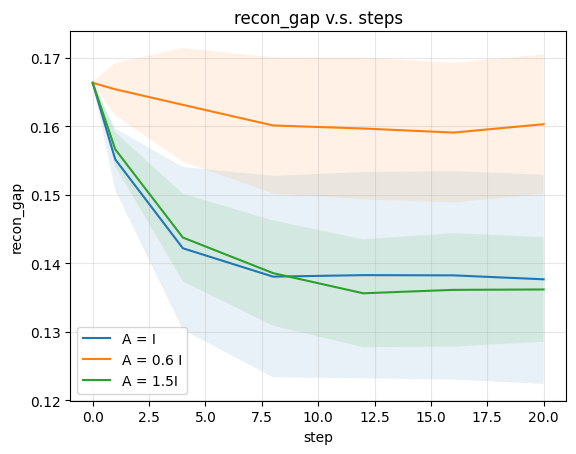

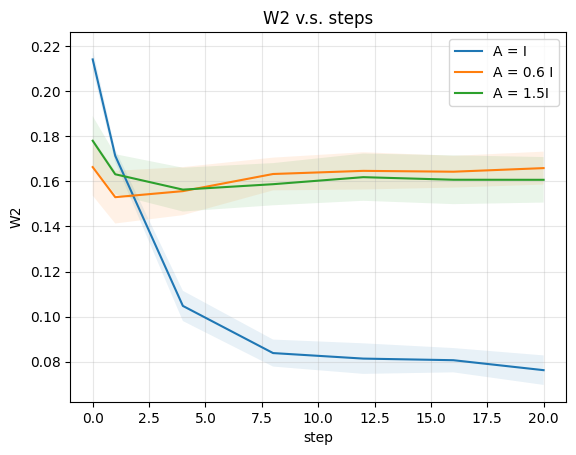

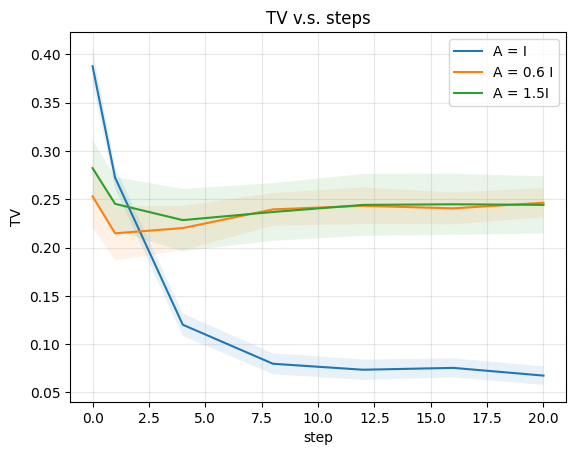

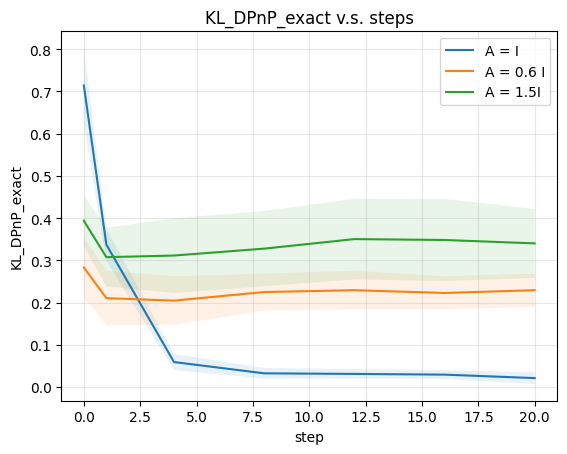

In [25]:
plot_summaries(
    summaries=[df_summary3,df_summary4, df_summary5 ],
    metric="recon_gap",
    labels=["A = I", "A = 0.6 I", "A = 1.5I"],
    num_trials=5
)

plot_summaries(
    summaries=[df_summary3,df_summary4, df_summary5 ],
    metric="W2",
    labels=["A = I", "A = 0.6 I", "A = 1.5I"],
    num_trials=5
)

plot_summaries(
    summaries=[df_summary3,df_summary4, df_summary5 ],
    metric="TV",
    labels=["A = I", "A = 0.6 I", "A = 1.5I"],
    num_trials=5
)

plot_summaries(
    summaries=[df_summary3,df_summary4, df_summary5 ],
    metric="KL_DPnP_exact",
    labels=["A = I", "A = 0.6 I", "A = 1.5I"],
    num_trials=5
)